In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

FIGURE_DIR = './figures/nb03'
os.makedirs(FIGURE_DIR, exist_ok=True)


# Load crime data
df = pd.read_parquet('./data/chicago_crimes_clean.parquet',
                     columns=['year', 'community_area', 'primary_type'])
df = df[(df['year'] >= 2001) & (df['year'] <= 2025)].copy()
print(f"Crime data: {len(df):,} rows")

# Load community area boundaries
gdf_ca = gpd.read_file('./data/community_areas.geojson')

ca_num_col = None
name_col = None
for col in gdf_ca.columns:
    if 'area_num' in col.lower():
        ca_num_col = col
    if 'community' in col.lower() and ('name' in col.lower() or col.lower() == 'community'):
        name_col = col

gdf_ca[ca_num_col] = pd.to_numeric(gdf_ca[ca_num_col], errors='coerce')
print(f"Community areas: {len(gdf_ca)}")
print(f"Area number col: '{ca_num_col}', Name col: '{name_col}'")

Crime data: 8,367,792 rows
Community areas: 77
Area number col: 'area_num_1', Name col: 'community'


In [2]:
# 1. Prepare Spatial Data

# Aggregate crime counts by community area and merge with geometries.

# Total crime count per community area
ca_crimes = df.groupby('community_area').size().reset_index(name='crime_count')
ca_crimes['community_area'] = ca_crimes['community_area'].astype(float)

gdf = gdf_ca.merge(ca_crimes, left_on=ca_num_col, right_on='community_area', how='left')
gdf['crime_count'] = gdf['crime_count'].fillna(0)

# Also compute crime rate per unit area (km^2) for a fairer comparison
# Project to a metric CRS for area calculation
gdf_proj = gdf.to_crs(epsg=26916)  # NAD83 / UTM zone 16N (covers Chicago)
gdf['area_km2'] = gdf_proj.geometry.area / 1e6
gdf['crime_rate'] = gdf['crime_count'] / gdf['area_km2']

print(f"Community areas with crime data: {(gdf['crime_count'] > 0).sum()}")
print(f"\nCrime count stats:")
print(gdf['crime_count'].describe().to_string())
print(f"\nCrime rate (per km^2) stats:")
print(gdf['crime_rate'].describe().to_string())
gdf['crime_count'] = gdf['crime_count'].astype(float)

Community areas with crime data: 77

Crime count stats:
count        77.000000
mean     100834.311688
std       83194.772781
min        7804.000000
25%       38914.000000
50%       71821.000000
75%      143438.000000
max      477519.000000

Crime rate (per km^2) stats:
count       77.000000
mean     14184.871342
std       9546.461889
min       1317.140639
25%       7254.382606
50%      12489.371455
75%      19837.613766
max      46406.963279


In [ ]:
# 2. Spatial Weights Matrix

# The spatial weights matrix defines the neighborhood structure.
# We use **Queen contiguity** (two areas are neighbors if they share any boundary point, including corners). This is the standard choice


from libpysal.weights import Queen

w = Queen.from_dataframe(gdf, use_index=False)
w.transform = 'R'  # Row-standardize

print(f"Spatial weights: Queen contiguity")
print(f"  Number of areas: {w.n}")
print(f"  Min neighbors: {w.min_neighbors}")
print(f"  Max neighbors: {w.max_neighbors}")
print(f"  Mean neighbors: {w.mean_neighbors:.1f}")
print(f"  Islands (no neighbors): {len(w.islands)}")

if len(w.islands) > 0:
    island_names = gdf.iloc[w.islands][name_col].tolist() if name_col else w.islands
    print(f"  Island areas: {island_names}")

# Visualize the connectivity graph
fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(ax=ax, edgecolor='gray', facecolor='lightgray', linewidth=0.5)

# Draw edges between connected neighbors
for i, (key, neighbors) in enumerate(w.neighbors.items()):
    origin = gdf.geometry.iloc[key].centroid
    for j in neighbors:
        dest = gdf.geometry.iloc[j].centroid
        ax.plot([origin.x, dest.x], [origin.y, dest.y],
                color='#1976D2', linewidth=0.5, alpha=0.6)

ax.set_title('Queen Contiguity Spatial Weights', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_spatial_weights.png'), dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# 3. Global Moran's I
# Tests whether crime counts across Chicago's 77 community areas
# exhibit statistically significant spatial clustering.

# - H0: Crime is randomly distributed (no spatial autocorrelation)
# - H1: Crime exhibits spatial clustering (positive autocorrelation)

# We use 9999 random permutations to assess significance.


from esda.moran import Moran

# Test on crime count
moran_count = Moran(gdf['crime_count'].values, w, permutations=9999)

print("=" * 60)
print("Global Moran's I — Crime Count")
print("=" * 60)
print(f"  Moran's I:       {moran_count.I:.4f}")
print(f"  Expected I:      {moran_count.EI:.4f}")
print(f"  Variance:        {moran_count.VI_sim:.6f}")
print(f"  Z-score:         {moran_count.z_sim:.4f}")
print(f"  p-value (sim):   {moran_count.p_sim:.6f}")
print(f"  Permutations:    {moran_count.permutations}")
if moran_count.p_sim < 0.001:
    print(f"  Result: *** Highly significant (p < 0.001)")
elif moran_count.p_sim < 0.01:
    print(f"  Result: ** Significant (p < 0.01)")
elif moran_count.p_sim < 0.05:
    print(f"  Result: * Significant (p < 0.05)")
else:
    print(f"  Result: Not significant")

# Test on crime rate (per km^2) as well
moran_rate = Moran(gdf['crime_rate'].values, w, permutations=9999)

print("\n" + "=" * 60)
print("Global Moran's I — Crime Rate (per km^2)")
print("=" * 60)
print(f"  Moran's I:       {moran_rate.I:.4f}")
print(f"  Expected I:      {moran_rate.EI:.4f}")
print(f"  Z-score:         {moran_rate.z_sim:.4f}")
print(f"  p-value (sim):   {moran_rate.p_sim:.6f}")

# 3.1 Moran Scatter Plot

# The Moran scatter plot visualizes the relationship between each area's value (x-axis) and the spatially lagged value (average of neighbors,
# y-axis). The four quadrants correspond to HH, LH, LL, HL clusters.

from splot.esda import moran_scatterplot, plot_moran_simulation

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Moran scatter plot
moran_scatterplot(moran_count, ax=axes[0], aspect_equal=False)
axes[0].set_title(f"Moran Scatter Plot (I={moran_count.I:.4f}, p={moran_count.p_sim:.4f})",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Crime Count (standardized)')
axes[0].set_ylabel('Spatial Lag of Crime Count')

# Reference distribution from permutation test
plot_moran_simulation(moran_count, ax=axes[1], aspect_equal=False)
axes[1].set_title('Permutation Test Reference Distribution',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_moran_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

LISA Cluster Summary (p < 0.05):

  Not Significant            62 community areas
  HH (Hot Spot)               9 community areas
  LL (Cold Spot)              3 community areas
  LH (Outlier)                2 community areas
  HL (Outlier)                1 community areas

Significant HH (Hot Spots):
  LINCOLN PARK                   crimes=   121,150  p=0.0450
  NEAR NORTH SIDE                crimes=   279,992  p=0.0260
  HUMBOLDT PARK                  crimes=   239,763  p=0.0090
  WEST TOWN                      crimes=   228,242  p=0.0090
  WEST GARFIELD PARK             crimes=   143,664  p=0.0010
  EAST GARFIELD PARK             crimes=   143,438  p=0.0060
  NEAR WEST SIDE                 crimes=   242,867  p=0.0330
  NORTH LAWNDALE                 crimes=   224,577  p=0.0080
  AUBURN GRESHAM                 crimes=   218,884  p=0.0320

Significant LL (Cold Spots):
  NORWOOD PARK                   crimes=    34,207  p=0.0020
  ALBANY PARK                    crimes=    70,192  p=0.0

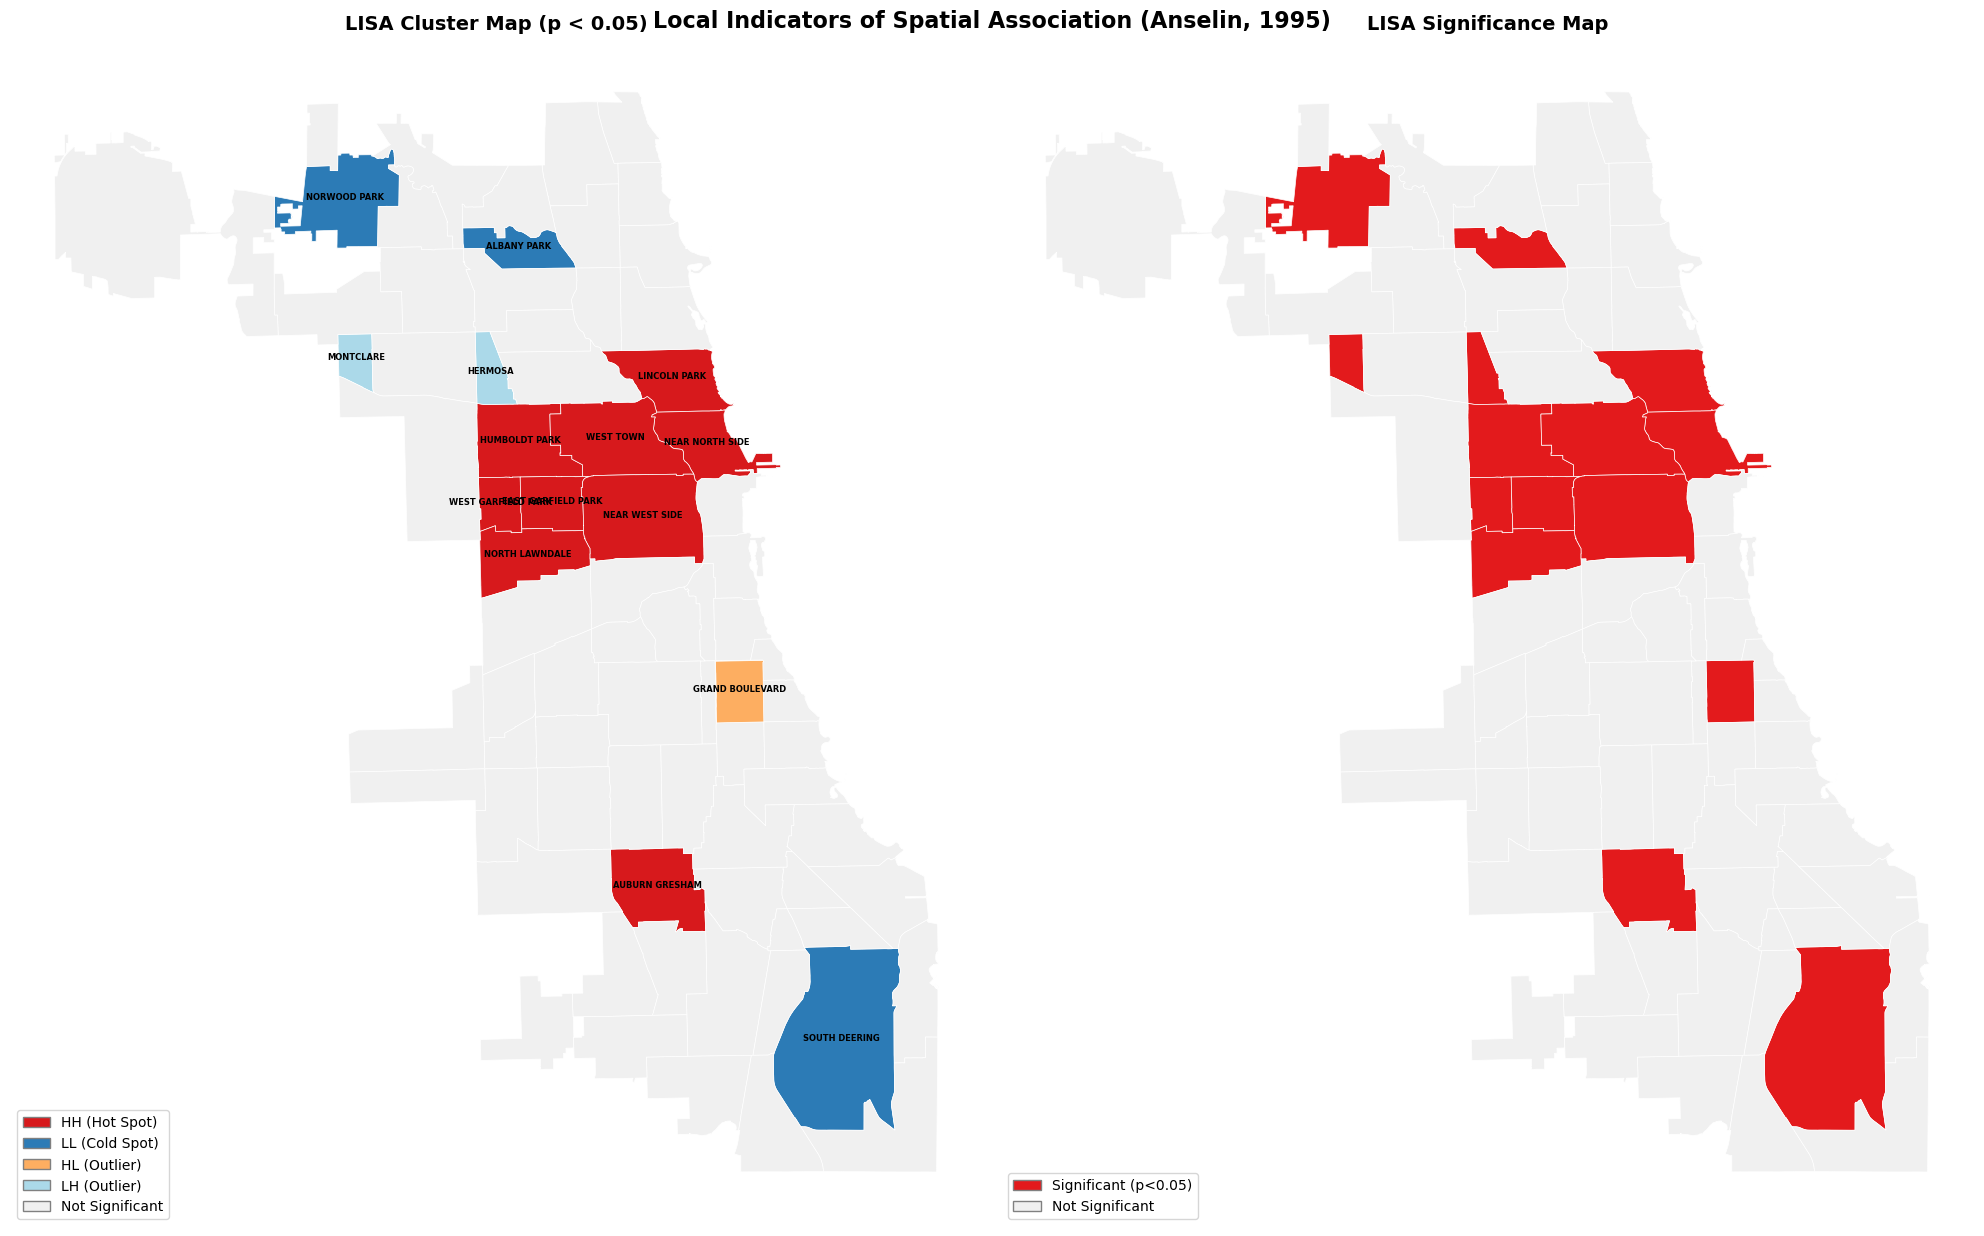

In [13]:
# 4. LISA — Local Indicators of Spatial Association

# LISA decomposes Global Moran's I into per-area contributions,
# classifying each community area into one of four types (Anselin, 1995):

from esda.moran import Moran_Local

lisa = Moran_Local(gdf['crime_count'].values, w, permutations=9999)

# Assign LISA cluster labels
# lisa.q values: 1=HH, 2=LH, 3=LL, 4=HL
sig_threshold = 0.05
gdf['lisa_q'] = lisa.q
gdf['lisa_p'] = lisa.p_sim
gdf['lisa_I'] = lisa.Is
gdf['lisa_sig'] = lisa.p_sim < sig_threshold

# Create cluster label
cluster_labels = {1: 'HH (Hot Spot)', 2: 'LH (Outlier)',
                  3: 'LL (Cold Spot)', 4: 'HL (Outlier)'}
gdf['lisa_cluster'] = 'Not Significant'
for idx in gdf.index:
    if gdf.loc[idx, 'lisa_sig']:
        gdf.loc[idx, 'lisa_cluster'] = cluster_labels.get(gdf.loc[idx, 'lisa_q'], 'NS')

cluster_counts = gdf['lisa_cluster'].value_counts()
print("LISA Cluster Summary (p < 0.05):\n")
for cluster, count in cluster_counts.items():
    print(f"  {cluster:<25s} {count:>3d} community areas")

# Print which communities are in each significant cluster
print("\nSignificant HH (Hot Spots):")
hh = gdf[gdf['lisa_cluster'] == 'HH (Hot Spot)']
for _, r in hh.iterrows():
    nm = r[name_col] if name_col else f"CA {r[ca_num_col]:.0f}"
    print(f"  {nm:<30s} crimes={r['crime_count']:>10,.0f}  p={r['lisa_p']:.4f}")

print("\nSignificant LL (Cold Spots):")
ll = gdf[gdf['lisa_cluster'] == 'LL (Cold Spot)']
for _, r in ll.iterrows():
    nm = r[name_col] if name_col else f"CA {r[ca_num_col]:.0f}"
    print(f"  {nm:<30s} crimes={r['crime_count']:>10,.0f}  p={r['lisa_p']:.4f}")

print("\nSignificant Outliers (HL or LH):")
outliers = gdf[gdf['lisa_cluster'].str.contains('Outlier')]
for _, r in outliers.iterrows():
    nm = r[name_col] if name_col else f"CA {r[ca_num_col]:.0f}"
    print(f"  {nm:<30s} {r['lisa_cluster']:<15s} crimes={r['crime_count']:>10,.0f}  p={r['lisa_p']:.4f}")

# 4.1 LISA Cluster Map

cluster_colors = {
    'HH (Hot Spot)': '#d7191c',
    'LL (Cold Spot)': '#2c7bb6',
    'HL (Outlier)': '#fdae61',
    'LH (Outlier)': '#abd9e9',
    'Not Significant': '#f0f0f0'
}

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

# LISA Cluster Map
ax = axes[0]
for cluster, color in cluster_colors.items():
    subset = gdf[gdf['lisa_cluster'] == cluster]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5)
    
legend_elements = [Patch(facecolor=c, edgecolor='gray', label=l)
                   for l, c in cluster_colors.items() if l != 'Not Significant']
legend_elements.append(Patch(facecolor='#f0f0f0', edgecolor='gray', label='Not Significant'))
ax.legend(handles=legend_elements, loc='lower left', fontsize=10)
ax.set_title(f'LISA Cluster Map (p < {sig_threshold})',
             fontsize=14, fontweight='bold')
ax.axis('off')

# Label significant areas
for _, r in gdf[gdf['lisa_sig']].iterrows():
    c = r.geometry.centroid
    nm = r[name_col] if name_col else f"CA {r[ca_num_col]:.0f}"
    ax.annotate(nm, xy=(c.x, c.y), fontsize=6, ha='center', fontweight='bold')

# Significance Map
ax2 = axes[1]
sig_colors = {True: '#e31a1c', False: '#f0f0f0'}
for sig, color in sig_colors.items():
    subset = gdf[gdf['lisa_sig'] == sig]
    if len(subset) > 0:
        subset.plot(ax=ax2, color=color, edgecolor='white', linewidth=0.5)

legend_sig = [Patch(facecolor='#e31a1c', edgecolor='gray', label=f'Significant (p<{sig_threshold})'),
              Patch(facecolor='#f0f0f0', edgecolor='gray', label='Not Significant')]
ax2.legend(handles=legend_sig, loc='lower left', fontsize=10)
ax2.set_title(f'LISA Significance Map', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.suptitle('Local Indicators of Spatial Association (Anselin, 1995)',
             fontsize=16, fontweight='bold', y=0.93)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '03_lisa_cluster_map.png'), dpi=150, bbox_inches='tight')
plt.show()


Getis-Ord Gi* Classification:

  Not Significant            50
  Hot Spot (95%)              8
  Cold Spot (90%)             7
  Hot Spot (99%)              5
  Hot Spot (90%)              4
  Cold Spot (95%)             2
  Cold Spot (99%)             1


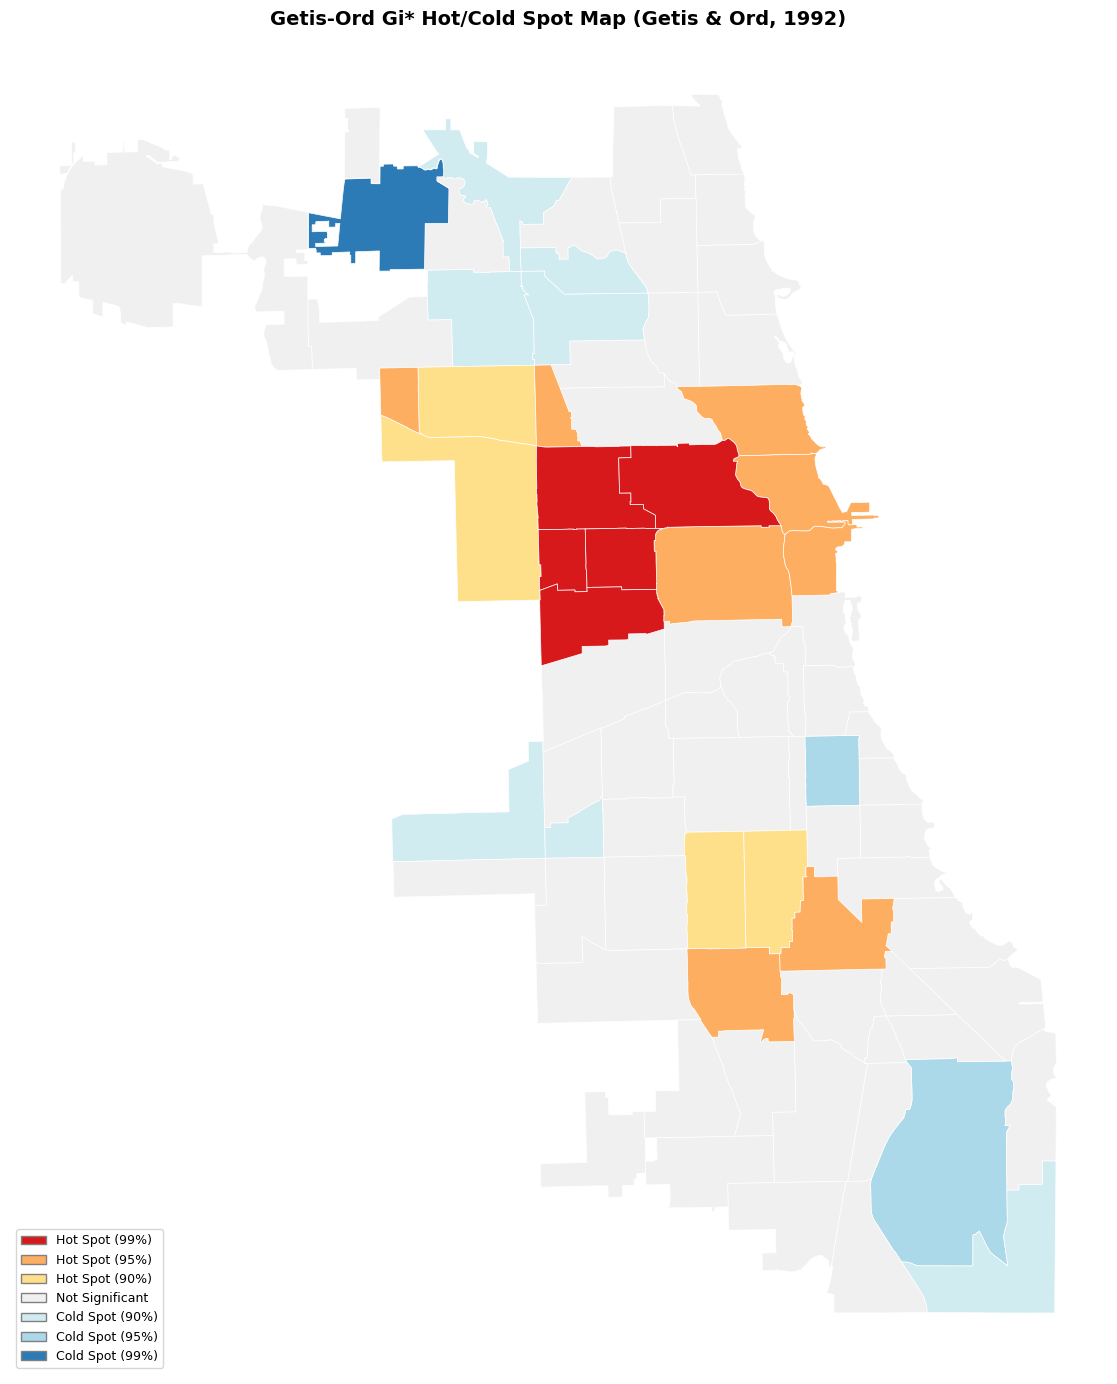

In [14]:
# 5. Getis-Ord Gi* Hot Spot Analysis

# While LISA identifies clusters relative to neighbors, Getis-Ord Gi*
# identifies statistically significant concentrations of high or low
# values (Getis & Ord, 1992). Areas with high Gi* z-scores are hot spots;
# areas with low z-scores are cold spots.

from esda.getisord import G_Local

gi_star = G_Local(gdf['crime_count'].values.astype(float), w, star=True, permutations=999)
gdf['gi_z'] = gi_star.Zs
gdf['gi_p'] = gi_star.p_sim

# Classify hot/cold spots at multiple confidence levels
def classify_gi(z, p):
    if p < 0.01 and z > 0:
        return 'Hot Spot (99%)'
    elif p < 0.05 and z > 0:
        return 'Hot Spot (95%)'
    elif p < 0.1 and z > 0:
        return 'Hot Spot (90%)'
    elif p < 0.01 and z < 0:
        return 'Cold Spot (99%)'
    elif p < 0.05 and z < 0:
        return 'Cold Spot (95%)'
    elif p < 0.1 and z < 0:
        return 'Cold Spot (90%)'
    else:
        return 'Not Significant'

gdf['gi_class'] = [classify_gi(z, p) for z, p in zip(gdf['gi_z'], gdf['gi_p'])]

gi_counts = gdf['gi_class'].value_counts()
print("Getis-Ord Gi* Classification:\n")
for cls, cnt in gi_counts.items():
    print(f"  {cls:<25s} {cnt:>3d}")

#
gi_colors = {
    'Hot Spot (99%)': '#d7191c',
    'Hot Spot (95%)': '#fdae61',
    'Hot Spot (90%)': '#fee08b',
    'Not Significant': '#f0f0f0',
    'Cold Spot (90%)': '#d1ecf1',
    'Cold Spot (95%)': '#abd9e9',
    'Cold Spot (99%)': '#2c7bb6',
}

fig, ax = plt.subplots(figsize=(12, 14))
for cls in ['Cold Spot (99%)', 'Cold Spot (95%)', 'Cold Spot (90%)',
            'Not Significant',
            'Hot Spot (90%)', 'Hot Spot (95%)', 'Hot Spot (99%)']:
    subset = gdf[gdf['gi_class'] == cls]
    if len(subset) > 0:
        subset.plot(ax=ax, color=gi_colors[cls], edgecolor='white', linewidth=0.5)

legend_gi = [Patch(facecolor=gi_colors[c], edgecolor='gray', label=c)
             for c in ['Hot Spot (99%)', 'Hot Spot (95%)', 'Hot Spot (90%)',
                        'Not Significant',
                        'Cold Spot (90%)', 'Cold Spot (95%)', 'Cold Spot (99%)']]
ax.legend(handles=legend_gi, loc='lower left', fontsize=9)
ax.set_title('Getis-Ord Gi* Hot/Cold Spot Map (Getis & Ord, 1992)',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '04_getis_ord_map.png'), dpi=150, bbox_inches='tight')
plt.show()


Moran's I by Year:

  Year         I         z         p    Sig
  --------------------------------------
  2001   -0.0158     -0.12    0.4873       
  2002    0.3170      4.66    0.0003    ***
  2003    0.3109      4.70    0.0001    ***
  2004    0.3236      4.95    0.0001    ***
  2005    0.3290      4.95    0.0001    ***
  2006    0.3151      4.75    0.0001    ***
  2007    0.3161      4.75    0.0001    ***
  2008    0.3195      4.76    0.0001    ***
  2009    0.3088      4.62    0.0001    ***
  2010    0.3281      4.93    0.0001    ***
  2011    0.3188      4.80    0.0002    ***
  2012    0.3416      5.13    0.0001    ***
  2013    0.3443      5.21    0.0001    ***
  2014    0.3424      5.14    0.0001    ***
  2015    0.3492      5.25    0.0001    ***
  2016    0.3728      5.57    0.0001    ***
  2017    0.3908      5.79    0.0001    ***
  2018    0.3980      5.80    0.0001    ***
  2019    0.4031      5.82    0.0001    ***
  2020    0.3460      5.19    0.0001    ***
  2021    0.345

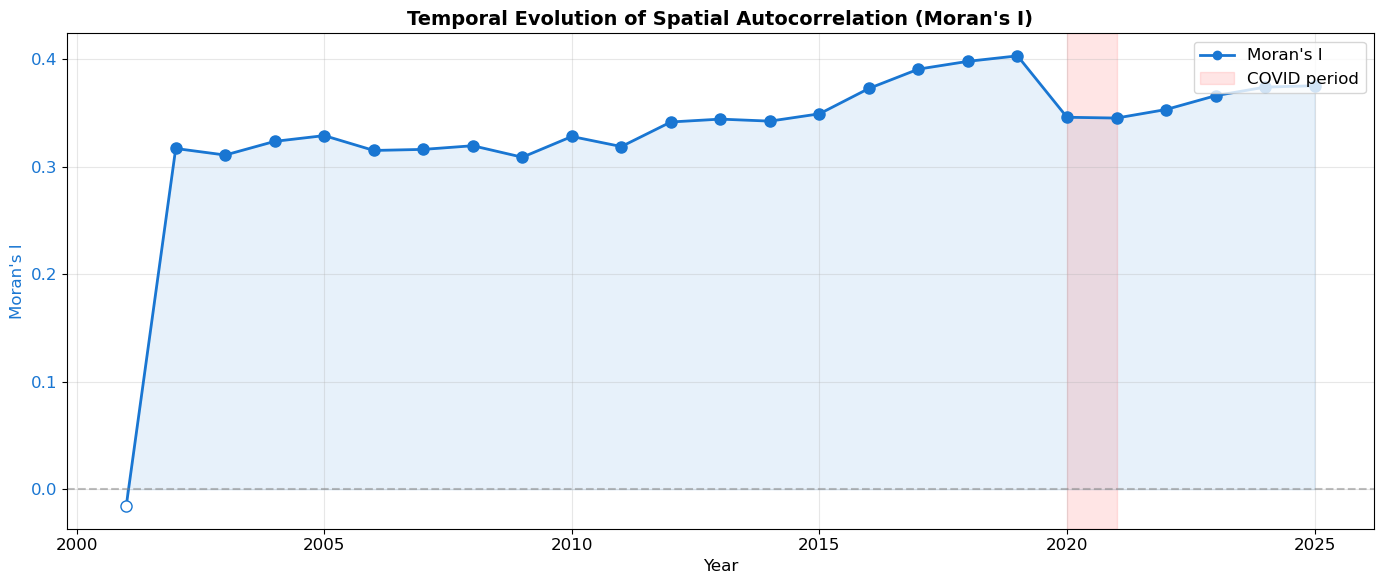


Moran's I range: [-0.0158, 0.4031]
All years significant (p<0.05): False


In [19]:
# 6. Temporal Evolution of Spatial Autocorrelation

# **This is an extension beyond the standard single-snapshot analysis.**
#
# We compute Global Moran's I for each year from 2001 to 2025 to track
# how the degree of spatial clustering evolves over time. This reveals:
# - Whether crime is becoming more or less spatially concentrated
# - Whether COVID disrupted the spatial structure of crime
# - Long-term trends in spatial inequality of crime burden


years = range(2001, 2026)
moran_by_year = []

for yr in years:
    yr_crimes = df[df['year'] == yr].groupby('community_area').size().reset_index(name='count')
    yr_crimes['community_area'] = yr_crimes['community_area'].astype(float)
    
    # Merge with geodataframe to ensure all 77 areas are included
    yr_gdf = gdf_ca[[ca_num_col, 'geometry']].copy()
    yr_gdf = yr_gdf.merge(yr_crimes, left_on=ca_num_col, right_on='community_area', how='left')
    yr_gdf['count'] = yr_gdf['count'].fillna(0)
    
    mi = Moran(yr_gdf['count'].values, w, permutations=9999)
    moran_by_year.append({
        'year': yr,
        'I': mi.I,
        'p_sim': mi.p_sim,
        'z_sim': mi.z_sim
    })

moran_ts = pd.DataFrame(moran_by_year)

print("Moran's I by Year:\n")
print(f"  {'Year':>4s}  {'I':>8s}  {'z':>8s}  {'p':>8s}  {'Sig':>5s}")
print(f"  {'-'*38}")
for _, r in moran_ts.iterrows():
    sig = '***' if r['p_sim'] < 0.001 else ('**' if r['p_sim'] < 0.01 else ('*' if r['p_sim'] < 0.05 else ''))
    print(f"  {int(r['year']):>4d}  {r['I']:>8.4f}  {r['z_sim']:>8.2f}  {r['p_sim']:>8.4f}  {sig:>5s}")


fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(moran_ts['year'], moran_ts['I'], 'o-', color='#1976D2', lw=2, ms=6, label="Moran's I")
ax1.fill_between(moran_ts['year'], moran_ts['I'], alpha=0.1, color='#1976D2')
ax1.set_xlabel('Year')
ax1.set_ylabel("Moran's I", color='#1976D2')
ax1.tick_params(axis='y', labelcolor='#1976D2')

# Mark significance
for _, r in moran_ts.iterrows():
    if r['p_sim'] < 0.05:
        ax1.plot(r['year'], r['I'], 'o', color='#1976D2', ms=8, zorder=5)
    else:
        ax1.plot(r['year'], r['I'], 'o', color='white', mec='#1976D2', ms=8, zorder=5)

ax1.axhline(0, color='gray', ls='--', alpha=0.5)
ax1.axvspan(2020, 2021, alpha=0.1, color='red', label='COVID period')

ax1.set_title("Temporal Evolution of Spatial Autocorrelation (Moran's I)",
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '05_moran_temporal.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMoran's I range: [{moran_ts['I'].min():.4f}, {moran_ts['I'].max():.4f}]")
print(f"All years significant (p<0.05): {(moran_ts['p_sim'] < 0.05).all()}")


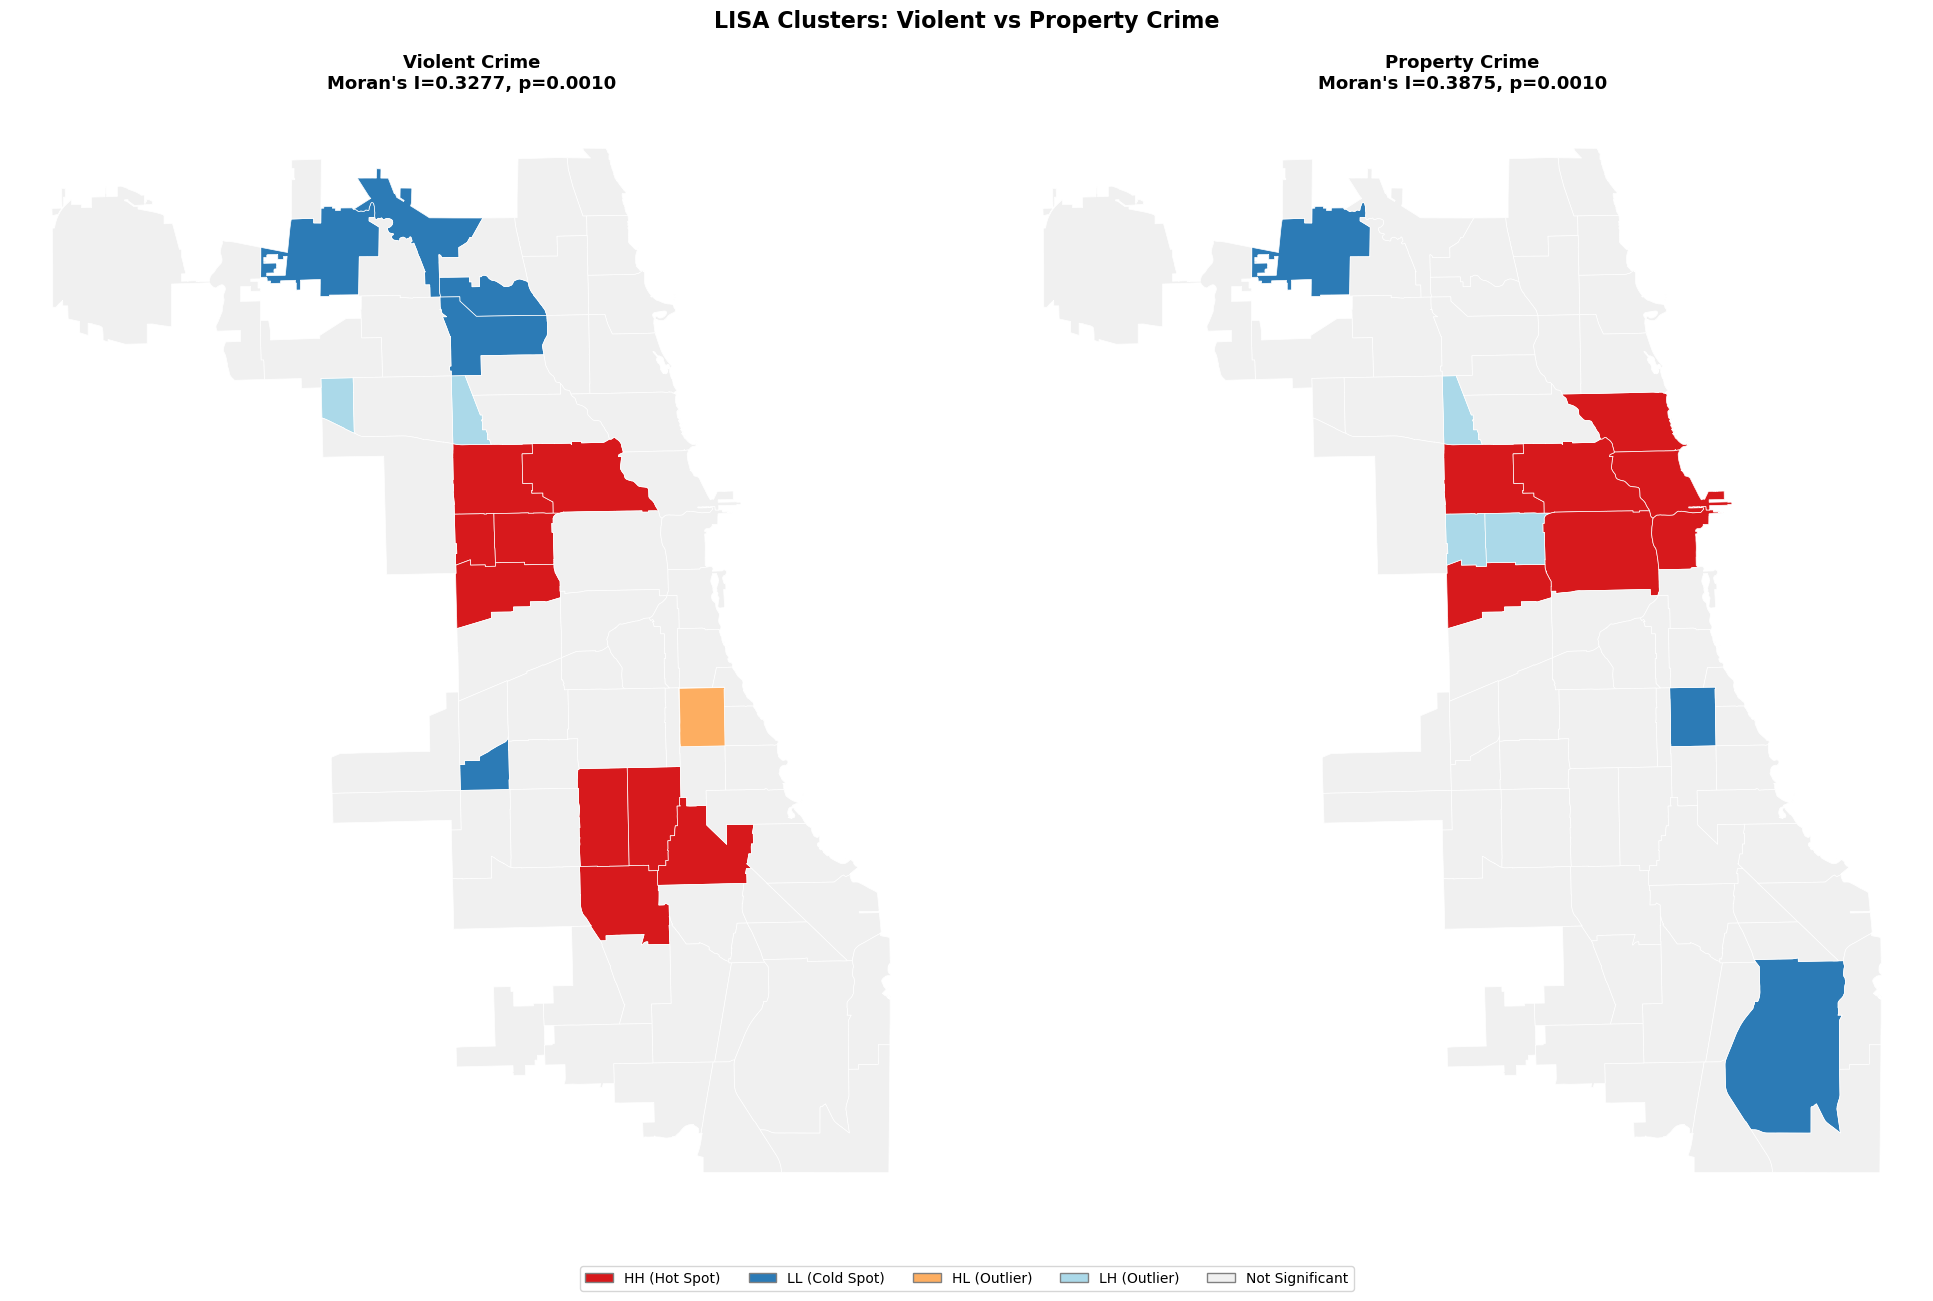

In [16]:
# 7. LISA by Crime Category
# **Another extension**: Compare spatial clustering patterns between
# violent and property crime. This tests whether different crime types
# have fundamentally different spatial structures.

violent_types = ['BATTERY', 'ASSAULT', 'HOMICIDE', 'ROBBERY',
                 'CRIM SEXUAL ASSAULT', 'CRIMINAL SEXUAL ASSAULT']
property_types = ['THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT',
                  'CRIMINAL DAMAGE', 'ARSON']

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

for ax, (cat_name, type_list) in zip(axes, [('Violent', violent_types),
                                              ('Property', property_types)]):
    sub = df[df['primary_type'].isin(type_list)]
    ca_sub = sub.groupby('community_area').size().reset_index(name='count')
    ca_sub['community_area'] = ca_sub['community_area'].astype(float)
    
    gdf_sub = gdf_ca[[ca_num_col, 'geometry']].copy()
    gdf_sub = gdf_sub.merge(ca_sub, left_on=ca_num_col, right_on='community_area', how='left')
    gdf_sub['count'] = gdf_sub['count'].fillna(0)
    
    # Global Moran's I
    mi = Moran(gdf_sub['count'].values, w, permutations=999)
    
    # LISA
    li = Moran_Local(gdf_sub['count'].values, w, permutations=999)
    gdf_sub['cluster'] = 'Not Significant'
    for idx in gdf_sub.index:
        if li.p_sim[idx] < 0.05:
            gdf_sub.loc[idx, 'cluster'] = cluster_labels.get(li.q[idx], 'NS')
    
    # Plot
    for cluster, color in cluster_colors.items():
        subset = gdf_sub[gdf_sub['cluster'] == cluster]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5)
    
    ax.set_title(f"{cat_name} Crime\nMoran's I={mi.I:.4f}, p={mi.p_sim:.4f}",
                 fontsize=13, fontweight='bold')
    ax.axis('off')
    
    # Label significant areas
    for idx in gdf_sub.index:
        if gdf_sub.loc[idx, 'cluster'] != 'Not Significant' and name_col:
            c = gdf_sub.loc[idx, 'geometry'].centroid
            ax.annotate(gdf_sub.loc[idx, name_col] if name_col in gdf_sub.columns
                       else '', xy=(c.x, c.y), fontsize=5, ha='center')

# Shared legend
legend_elements = [Patch(facecolor=c, edgecolor='gray', label=l)
                   for l, c in cluster_colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, 0.02))
plt.suptitle('LISA Clusters: Violent vs Property Crime',
             fontsize=16, fontweight='bold', y=0.94)
plt.tight_layout(rect=[0, 0.06, 1, 0.92])
plt.savefig(os.path.join(FIGURE_DIR, '06_lisa_by_category.png'), dpi=150, bbox_inches='tight')
plt.show()

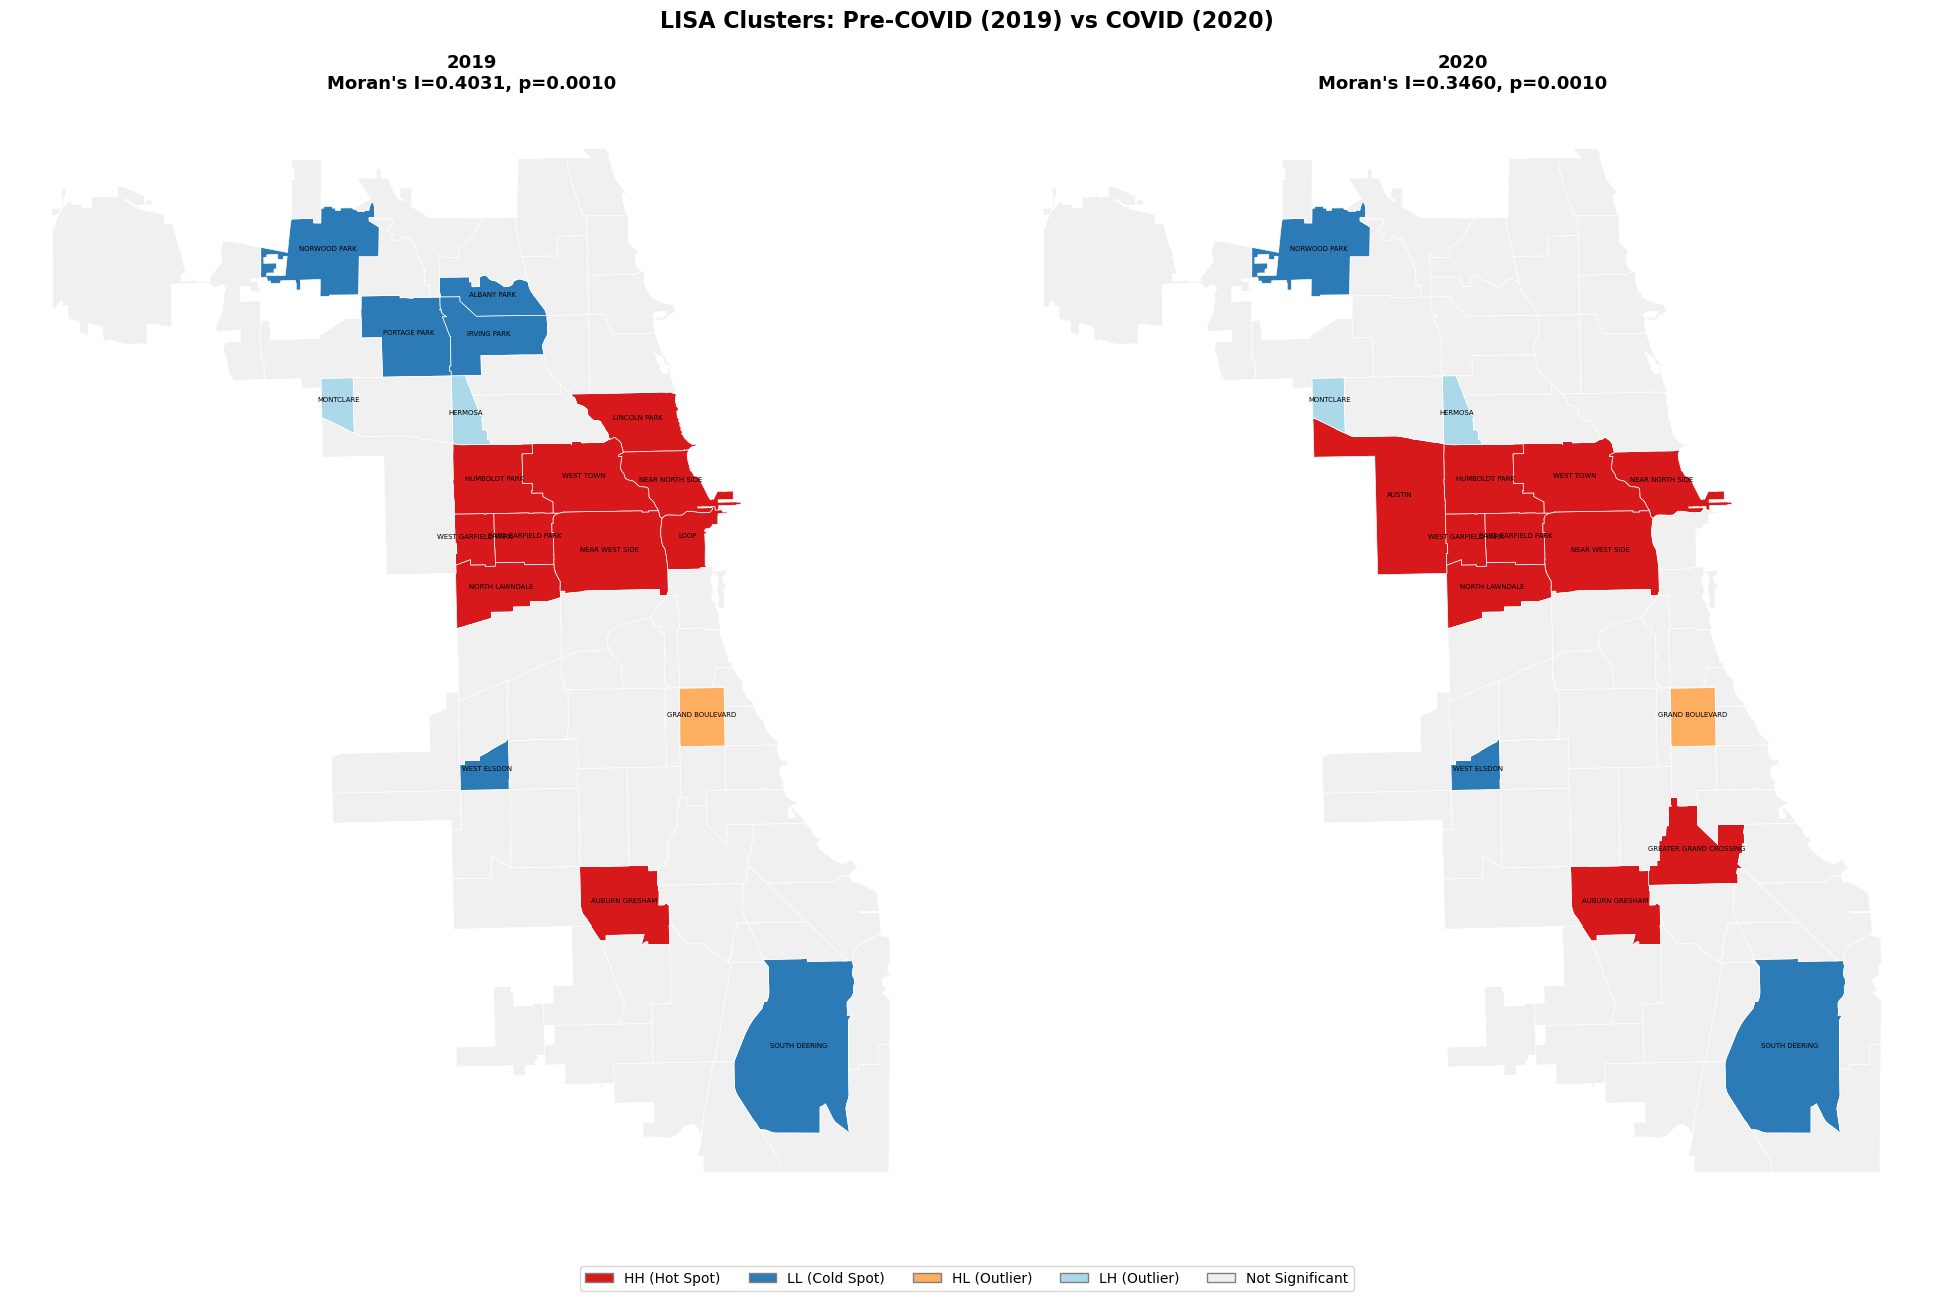

In [17]:
# 8. Pre-COVID vs COVID LISA Comparison

# Compare LISA cluster maps for 2019 (pre-COVID) and 2020 (COVID) to test whether the pandemic disrupted the spatial structure of crime.

fig, axes = plt.subplots(1, 2, figsize=(20, 14))

for ax, yr in zip(axes, [2019, 2020]):
    yr_sub = df[df['year'] == yr]
    ca_yr = yr_sub.groupby('community_area').size().reset_index(name='count')
    ca_yr['community_area'] = ca_yr['community_area'].astype(float)
    
    gdf_yr = gdf_ca[[ca_num_col, 'geometry']].copy()
    if name_col:
        gdf_yr[name_col] = gdf_ca[name_col]
    gdf_yr = gdf_yr.merge(ca_yr, left_on=ca_num_col, right_on='community_area', how='left')
    gdf_yr['count'] = gdf_yr['count'].fillna(0)
    
    mi = Moran(gdf_yr['count'].values, w, permutations=999)
    li = Moran_Local(gdf_yr['count'].values, w, permutations=999)
    
    gdf_yr['cluster'] = 'Not Significant'
    for idx in gdf_yr.index:
        if li.p_sim[idx] < 0.05:
            gdf_yr.loc[idx, 'cluster'] = cluster_labels.get(li.q[idx], 'NS')
    
    for cluster, color in cluster_colors.items():
        subset = gdf_yr[gdf_yr['cluster'] == cluster]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.5)
    
    ax.set_title(f"{yr}\nMoran's I={mi.I:.4f}, p={mi.p_sim:.4f}",
                 fontsize=13, fontweight='bold')
    ax.axis('off')
    
    for idx in gdf_yr.index:
        if gdf_yr.loc[idx, 'cluster'] != 'Not Significant' and name_col:
            c = gdf_yr.loc[idx, 'geometry'].centroid
            nm = gdf_yr.loc[idx, name_col] if name_col in gdf_yr.columns else ''
            ax.annotate(nm, xy=(c.x, c.y), fontsize=5, ha='center')

fig.legend(handles=legend_elements, loc='lower center', ncol=5, fontsize=10,
           bbox_to_anchor=(0.5, 0.02))
plt.suptitle('LISA Clusters: Pre-COVID (2019) vs COVID (2020)',
             fontsize=16, fontweight='bold', y=0.94)
plt.tight_layout(rect=[0, 0.06, 1, 0.92])
plt.savefig(os.path.join(FIGURE_DIR, '07_lisa_covid_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()